# 离散信号的 Z 变换与逆 Z 变换：SymPy 和 Matplotlib 演示

**目标：** 本 Notebook 说明离散时间信号的双边 Z 变换及其逆变换的定义、应用场景和工程意义。随后以因果指数序列 $x[n]=a^n u[n]$ 为例，使用 `sympy` 对 Z 变换、逆变换（留数法）和级数展开进行符号推导，并使用 `matplotlib` 绘制支持中文标注的序列、频率响应和极零图。

> 建议运行环境：Python 3.10+，SymPy，NumPy，Matplotlib。Notebook 会尝试自动选择已安装的中文字体。

## 1. 定义与符号约定

对离散时间序列 $x[n]$，其**双边 Z 变换**定义为：

$$
X(z)=\mathcal{Z}\{x[n]\}=\sum_{n=-\infty}^{\infty}x[n]z^{-n},
$$

其中 $z\in\mathbb{C}$ 是复变量，可写为 $z=re^{j\omega}$。使该无穷级数收敛的 $z$ 的集合称为**收敛域**（Region of Convergence, ROC）。在实际系统分析中，Z 变换的代数式必须与收敛域一起解释，因为相同的代数式配合不同的 ROC 可能对应不同序列。[1]

逆 Z 变换的复积分形式为：

$$
x[n]=\mathcal{Z}^{-1}\{X(z)\}=\frac{1}{2\pi j}\oint_{C}X(z)z^{n-1}\,\mathrm{d}z,
$$

其中闭合路径 $C$ 取在收敛域内。对有理函数，逆变换常通过部分分式、幂级数展开或**留数法**得到。

> 当收敛域包含单位圆 $|z|=1$ 时，令 $z=e^{j\omega}$，则 $X(e^{j\omega})$ 给出该序列的离散时间傅里叶变换（DTFT）。

## 2. 应用场景与意义

Z 变换是离散时间信号与系统分析的基本工具。它将时域中的移位、差分和卷积运算转换为 $z$ 域中的代数运算，使数字滤波器、递归系统和离散控制系统的分析更加直接。

| 场景 | Z 变换的作用 | 工程意义 |
|---|---|---|
| 数字滤波器设计 | 用传递函数 $H(z)$ 描述 FIR/IIR 滤波器 | 便于分析频率选择性和实现结构 |
| 差分方程求解 | 将时域差分方程转化为关于 $z$ 的代数方程 | 可系统求解零状态与零输入响应 |
| 稳定性分析 | 根据极点位置与 ROC 判断系统性质 | 因果 LTI 系统稳定时，极点应位于单位圆内 |
| 离散控制 | 表达采样系统的脉冲传递函数 | 用于极点配置、离散补偿和闭环设计 |
| 频谱分析 | 在单位圆上评价 $H(e^{j\omega})$ | 可得到数字系统的幅频和相频特性 |

> **重要理解：** Z 变换是离散时间序列的复频域表示；极点、零点和收敛域共同决定系统的动态特性、因果性与稳定性。

## 3. 导入库并设置中文绘图字体

以下代码按优先级检测常见中文字体。设置 `axes.unicode_minus=False` 可以避免坐标轴中的负号显示异常。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
import sympy as sp
from sympy import I, oo, residue, simplify, summation, symbols

# 按优先级选择中文字体；不同操作系统的字体名称可能不同。
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = [
    'Noto Sans CJK SC', 'Noto Sans CJK', 'WenQuanYi Zen Hei',
    'SimHei', 'Microsoft YaHei', 'PingFang SC', 'Arial Unicode MS'
]
selected_font = next((name for name in font_candidates if name in available_fonts), 'DejaVu Sans')

plt.rcParams['font.sans-serif'] = [selected_font]
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print(f'当前绘图字体：{selected_font}')
print(f'SymPy 版本：{sp.__version__}')

当前绘图字体：SimHei
SymPy 版本：1.14.0


## 4. 使用 SymPy 计算 Z 变换

选取因果指数序列

$$
x[n]=a^n u[n],\qquad 0<a<1,
$$

其中 $u[n]$ 为单位阶跃序列，因而 $x[n]=0$（$n<0$）、$x[n]=a^n$（$n\ge 0$）。根据定义：

$$
X(z)=\sum_{n=0}^{\infty}a^n z^{-n}
=\sum_{n=0}^{\infty}\left(\frac{a}{z}\right)^n
=\frac{1}{1-az^{-1}}=\frac{z}{z-a},\qquad |z|>|a|.
$$

下面用 SymPy 的 `summation` 从无穷级数出发计算。由于当前 SymPy 并未提供单独的 Z 变换接口，本例使用其通用的符号求和、化简、留数和级数展开能力实现 Z 变换及逆变换。[2]

In [2]:
# 设 a 为正数；m 是求和用的整数索引，n 是离散时间索引。
a = symbols('a', positive=True, real=True)
z = symbols('z')
m = symbols('m', integer=True, nonnegative=True)
n = symbols('n', integer=True, nonnegative=True)

# x[m] = a^m u[m]；由于 m 从 0 开始，u[m] 已隐含在求和下限中。
x_m = a**m
X_from_definition = summation(x_m * z**(-m), (m, 0, oo))

# 几何级数在 |a/z| < 1，即 |z| > |a| 时收敛；写出收敛域内的闭式。
X_z = simplify(z / (z - a))

print('序列 x[m] =')
sp.pprint(x_m)
print('\n按 Z 变换定义求和得到：')
sp.pprint(X_from_definition)
print('\n在 ROC：|z| > |a| 内，闭式结果 X(z) =')
sp.pprint(X_z)
print('\n极点：z = a；零点：z = 0。')

序列 x[m] =
 m
a 

按 Z 变换定义求和得到：
⎧     1              │1│    
⎪  ───────     for a⋅│─│ < 1
⎪    a               │z│    
⎪  - ─ + 1                  
⎪    z                      
⎪                           
⎪  ∞                        
⎨ ___                       
⎪ ╲                         
⎪  ╲    m  -m               
⎪  ╱   a ⋅z      otherwise  
⎪ ╱                         
⎪ ‾‾‾                       
⎪m = 0                      
⎩                           

在 ROC：|z| > |a| 内，闭式结果 X(z) =
  z   
──────
-a + z

极点：z = a；零点：z = 0。


## 5. 使用留数法和级数展开演示逆 Z 变换

对于因果序列，收敛域为 $|z|>|a|$。当 $n\ge0$ 时，逆 Z 变换积分中的被积函数为

$$
X(z)z^{n-1}=\frac{z^n}{z-a}.
$$

在取包围极点 $z=a$ 的闭合路径时，留数为 $a^n$，这就恢复了原序列。下面先用 `sympy.residue` 计算通项，再用 $z=\infty$ 附近的 Laurent 级数读取前若干个样本。

In [3]:
# 留数法：x[n] = Res{X(z) z^(n-1), z=a}，适用于此因果序列的 n >= 0。
x_from_residue = simplify(residue(X_z * z**(n - 1), z, a))
print('留数法得到的逆 Z 变换通项 x[n] =')
sp.pprint(x_from_residue)
print('\n通项一致性验证 x[n] - a^n =')
sp.pprint(simplify(x_from_residue - a**n))

# 在 z=∞ 处展开，z^{-n} 的系数即对应序列样本 x[n]。
laurent_series = sp.series(X_z, z, oo, 8)
print('\nX(z) 在 z=∞ 处的 Laurent 级数（前 8 项）=')
sp.pprint(laurent_series)

# 列出前 8 个逆变换样本并与原序列比较。
indices = list(range(8))
recovered_samples = [simplify(residue(X_z * z**(idx - 1), z, a)) for idx in indices]
expected_samples = [a**idx for idx in indices]
print('\n前 8 个由逆 Z 变换恢复的样本：')
print(recovered_samples)
print('逐项符号验证：', [simplify(left - right) for left, right in zip(recovered_samples, expected_samples)])

留数法得到的逆 Z 变换通项 x[n] =
 n
a 

通项一致性验证 x[n] - a^n =
0

X(z) 在 z=∞ 处的 Laurent 级数（前 8 项）=
         2    3    4    5    6    7               
    a   a    a    a    a    a    a     ⎛1        ⎞
1 + ─ + ── + ── + ── + ── + ── + ── + O⎜──; z → ∞⎟
    z    2    3    4    5    6    7    ⎜ 8       ⎟
        z    z    z    z    z    z     ⎝z        ⎠

前 8 个由逆 Z 变换恢复的样本：
[1, a, a**2, a**3, a**4, a**5, a**6, a**7]
逐项符号验证： [0, 0, 0, 0, 0, 0, 0, 0]


## 6. 绘制离散序列与单位圆上的频率响应

令 $a=0.72$。左图使用 stem 图显示时域离散序列。右图在单位圆 $z=e^{j\omega}$ 上绘制 $|X(e^{j\omega})|$，即 DTFT 的幅度。由于 $0<a<1$，ROC $|z|>a$ 包含单位圆，故单位圆上的响应存在。

C:\Users\yeshe\AppData\Local\Temp\ipykernel_36688\3275264632.py:33: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.tight_layout()
d:\Source\Repos\Visual Studio Code\sensors_and_intelligent_detection\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


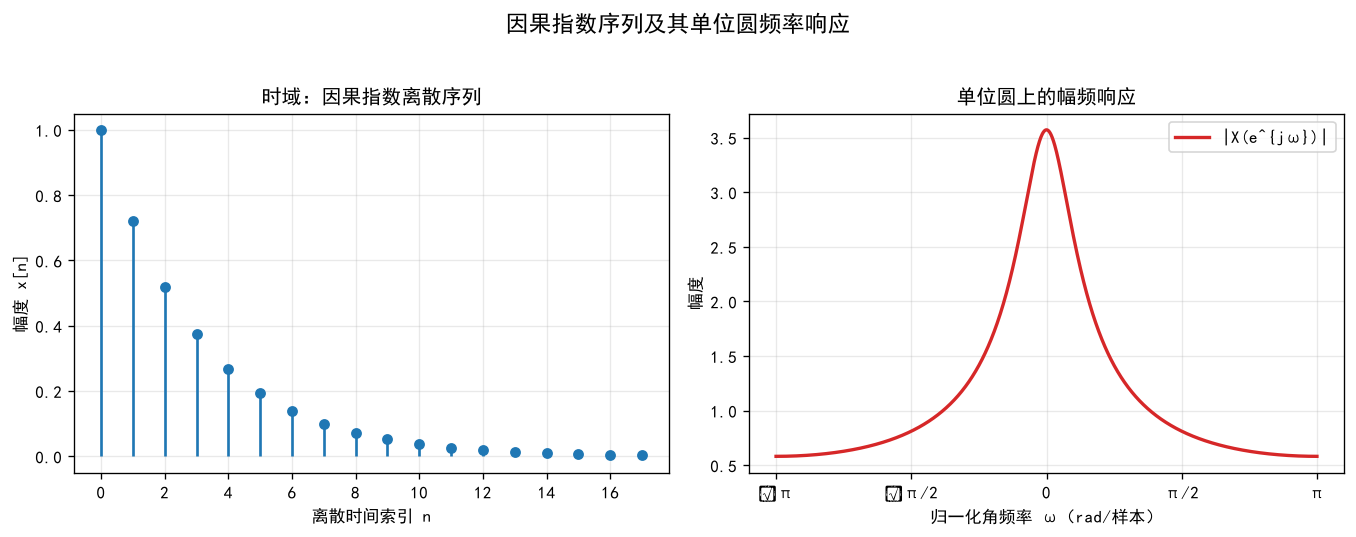

In [4]:
a_value = 0.72
sample_indices = np.arange(0, 18)
sample_values = a_value**sample_indices

# X(e^(jω))：将闭式 Z 变换表达式代入单位圆。
omega = symbols('omega', real=True)
X_unit_circle = X_z.subs({a: a_value, z: sp.exp(I * omega)})
X_unit_circle_fun = sp.lambdify(omega, X_unit_circle, modules='numpy')
omega_values = np.linspace(-np.pi, np.pi, 1600)
frequency_magnitude = np.abs(X_unit_circle_fun(omega_values))

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3))

markerline, stemlines, baseline = axes[0].stem(sample_indices, sample_values, basefmt=' ')
plt.setp(markerline, markerfacecolor='#1f77b4', markersize=5.5)
plt.setp(stemlines, color='#1f77b4', linewidth=1.6)
axes[0].set_title('时域：因果指数离散序列')
axes[0].set_xlabel('离散时间索引 n')
axes[0].set_ylabel('幅度 x[n]')
axes[0].set_xticks(np.arange(0, 18, 2))
axes[0].grid(True, alpha=0.28)

axes[1].plot(omega_values, frequency_magnitude, color='#d62728', linewidth=2.0, label='|X(e^{jω})|')
axes[1].set_title('单位圆上的幅频响应')
axes[1].set_xlabel('归一化角频率 ω（rad/样本）')
axes[1].set_ylabel('幅度')
axes[1].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
axes[1].set_xticklabels(['−π', '−π/2', '0', 'π/2', 'π'])
axes[1].grid(True, alpha=0.28)
axes[1].legend()

fig.suptitle('因果指数序列及其单位圆频率响应', fontsize=14, y=1.03)
fig.tight_layout()
plt.show()

## 7. 绘制 z 平面极零分布与逆变换重构结果

对 $X(z)=z/(z-a)$，零点位于原点，极点位于实轴上的 $z=a$。下图左侧绘制单位圆、零点与极点；阴影区域示意 ROC：$|z|>a$。右侧叠加原序列与由留数法逆变换得到的序列，并绘制误差。

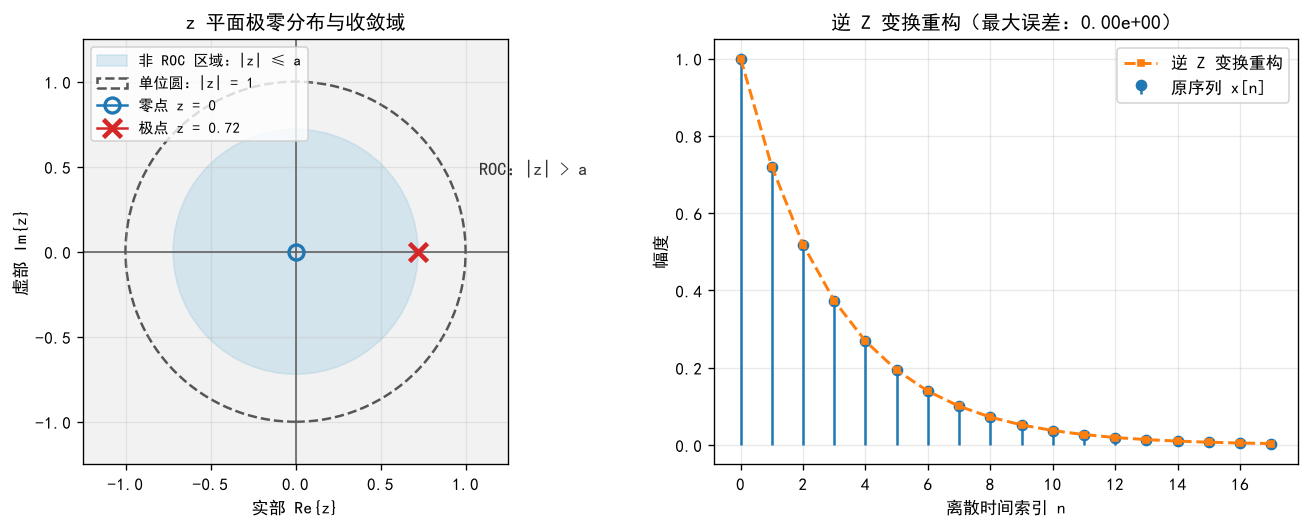

In [5]:
# 用留数法产生与原序列相同长度的重构样本。
reconstructed_values = np.array([
    float(residue(X_z * z**(int(idx) - 1), z, a).subs(a, a_value))
    for idx in sample_indices
])
error_values = np.abs(sample_values - reconstructed_values)

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.5))

# 左图：极零图和收敛域。
theta = np.linspace(0, 2 * np.pi, 600)
axes[0].fill_betweenx(np.linspace(-1.25, 1.25, 300), -1.25, 1.25, color='#f2f2f2', zorder=0)
roc_circle = plt.Circle((0, 0), a_value, color='#9ecae1', alpha=0.35, label='非 ROC 区域：|z| ≤ a')
unit_circle = plt.Circle((0, 0), 1, color='#555555', fill=False, linestyle='--', linewidth=1.5, label='单位圆：|z| = 1')
axes[0].add_patch(roc_circle)
axes[0].add_patch(unit_circle)
axes[0].axhline(0, color='#555555', linewidth=0.9)
axes[0].axvline(0, color='#555555', linewidth=0.9)
axes[0].plot(0, 0, marker='o', markersize=9, markerfacecolor='none', markeredgecolor='#1f77b4', markeredgewidth=2.0, label='零点 z = 0')
axes[0].plot(a_value, 0, marker='x', markersize=11, markeredgewidth=2.8, color='#d62728', label=f'极点 z = {a_value}')
axes[0].annotate('ROC：|z| > a', xy=(1.08, 0.45), fontsize=11, color='#333333')
axes[0].set_title('z 平面极零分布与收敛域')
axes[0].set_xlabel('实部 Re{z}')
axes[0].set_ylabel('虚部 Im{z}')
axes[0].set_xlim(-1.25, 1.25)
axes[0].set_ylim(-1.25, 1.25)
axes[0].set_aspect('equal', adjustable='box')
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc='upper left', fontsize=9)

# 右图：逆变换重构与逐点误差。
axes[1].stem(sample_indices, sample_values, linefmt='#1f77b4', markerfmt='o', basefmt=' ', label='原序列 x[n]')
axes[1].plot(sample_indices, reconstructed_values, color='#ff7f0e', linestyle='--', marker='s', markersize=4, linewidth=1.8, label='逆 Z 变换重构')
axes[1].set_title(f'逆 Z 变换重构（最大误差：{np.max(error_values):.2e}）')
axes[1].set_xlabel('离散时间索引 n')
axes[1].set_ylabel('幅度')
axes[1].set_xticks(np.arange(0, 18, 2))
axes[1].grid(True, alpha=0.28)
axes[1].legend()

fig.tight_layout()
plt.show()

## 8. 结论

本 Notebook 展示了如下要点：

1. **Z 变换**将离散序列映射到复平面变量 $z$ 上的函数，可将差分和卷积等时域问题转换为代数问题。
2. **收敛域**是 Z 变换表示不可分割的一部分，并与因果性、稳定性以及单位圆频率响应密切相关。
3. 对因果指数序列 $a^n u[n]$，在 ROC 为 $|z|>|a|$ 时，有 $X(z)=z/(z-a)$。SymPy 的符号求和得到这一结果，留数法和 Laurent 级数则恢复原序列。
4. 当 $0<a<1$ 时，极点位于单位圆内，且 ROC 包含单位圆；因此可在单位圆上得到有界的频率响应。
5. 通过中文字体配置，Matplotlib 的标题、坐标轴、图例和注释均可正确显示中文。

### 参考资料

[1] A. V. Oppenheim, R. W. Schafer. *Discrete-Time Signal Processing*, 3rd ed., Pearson, 2010.

[2] SymPy Development Team. *Sequences — SymPy Documentation*：https://docs.sympy.org/latest/modules/series/sequences.html
